# 🧪 SVM Student Lab
### Build your intuition — step by step, on real data

---

### 📌 What You Will Practise Today

| Concept | What it means in plain English |
|---|---|
| **Margin** | The gap between the two classes — SVM tries to make it as wide as possible |
| **Support Vectors** | The few training points that actually decide where the boundary goes |
| **C parameter** | How strict the model is. Small C = forgiving, large C = strict |
| **Kernels** | How the SVM draws its boundary — straight line, or curved |

### 🌍 Datasets We Use
| Dataset | What it is | Problem |
|---|---|---|
| **Breast Cancer** | 569 patients, 30 medical measurements | Is the tumour malignant or benign? |
| **Iris Flowers** | 150 flowers, 4 measurements | Which of 3 species is this flower? |
| **Digits** | 1797 handwritten digit images | Which digit 0–9 is this? |

### 📋 How to work through this
- Read each **Background** section carefully — the concept is explained there
- Then do the numbered steps in the code cell
- **💬 Think About It** boxes have questions — write your answers in the markdown cell
- Hidden solutions are available if you are stuck — but try first!

---

In [1]:
# ╔═══════════════════════════════════════╗
# ║  RUN THIS CELL FIRST — every time!   ║
# ╚═══════════════════════════════════════╝
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import warnings; warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Load all datasets
cancer = datasets.load_breast_cancer()
iris   = datasets.load_iris()
digits = datasets.load_digits()

print('✅ Ready to go!')
print(f'  Breast Cancer : {cancer.data.shape}')
print(f'  Iris          : {iris.data.shape}')
print(f'  Digits        : {digits.data.shape}')

✅ Ready to go!
  Breast Cancer : (569, 30)
  Iris          : (150, 4)
  Digits        : (1797, 64)


---
---
# 🏥 PART 1 — Breast Cancer
## "Can measurements of a tumour cell tell us if it is dangerous?"

Doctors take 30 measurements from each tumour cell (size, texture, smoothness, etc.)  
Your job: train an SVM to classify each tumour as **Malignant** (dangerous) or **Benign** (safe).

This is a real, life-or-death classification problem — which makes it perfect for building intuition about **what your model is actually doing**.

---

## ✏️ Task 1 — Look Before You Train

### Background
The first thing any data scientist does is **understand the data** before touching any model.  
Two things matter most:

1. **How many samples per class?** If 95% are benign and 5% malignant, a model that says "benign" every time would get 95% accuracy — but would miss every cancer case. This is called **class imbalance**.

2. **What do the features look like?** SVM uses distances between points. If one feature ranges from 0–1 and another from 0–10,000, the big one drowns out the small one. We fix this by **scaling**.

### Steps
1. Print: number of samples, number of features, class names
2. Print: how many samples per class
3. Make a **bar chart** — one bar per class, colour red for malignant, blue for benign
4. Look at the feature value ranges: print the **min and max** for all 30 features
5. Are the features on similar scales? Write your observation as a `print()`

> 💡 `cancer.data.min(axis=0)` → minimum value per feature  
> 💡 `cancer.data.max(axis=0)` → maximum value per feature  
> 💡 `np.sum(cancer.target == 0)` → count class 0

--- Step 1: Dataset Overview ---
Number of samples: 569
Number of features: 30
Class names: ['malignant' 'benign']

--- Step 2: Samples Per Class ---
Malignant (Class 0): 212
Benign (Class 1): 357

--- Step 3: Plotting Bar Chart ---


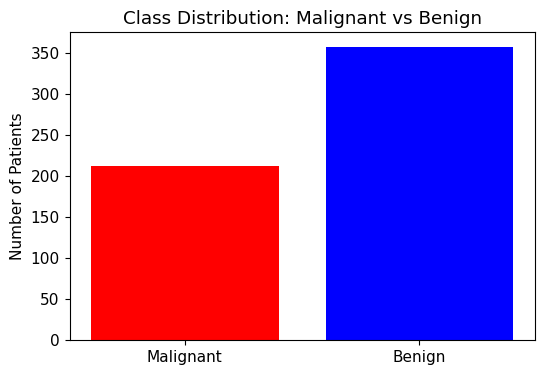


--- Step 4: Feature Value Ranges ---
Feature 1 (mean radius): Min = 6.981, Max = 28.110
Feature 2 (mean texture): Min = 9.710, Max = 39.280
Feature 3 (mean perimeter): Min = 43.790, Max = 188.500
Feature 4 (mean area): Min = 143.500, Max = 2501.000
Feature 5 (mean smoothness): Min = 0.053, Max = 0.163
Feature 6 (mean compactness): Min = 0.019, Max = 0.345
Feature 7 (mean concavity): Min = 0.000, Max = 0.427
Feature 8 (mean concave points): Min = 0.000, Max = 0.201
Feature 9 (mean symmetry): Min = 0.106, Max = 0.304
Feature 10 (mean fractal dimension): Min = 0.050, Max = 0.097
Feature 11 (radius error): Min = 0.112, Max = 2.873
Feature 12 (texture error): Min = 0.360, Max = 4.885
Feature 13 (perimeter error): Min = 0.757, Max = 21.980
Feature 14 (area error): Min = 6.802, Max = 542.200
Feature 15 (smoothness error): Min = 0.002, Max = 0.031
Feature 16 (compactness error): Min = 0.002, Max = 0.135
Feature 17 (concavity error): Min = 0.000, Max = 0.396
Feature 18 (concave points error): 

In [2]:
# ── Your code here ────────────────────────────────────────────────────────

# Step 1: Print dataset overview (Samples, Features, Class Names)
print("--- Step 1: Dataset Overview ---")
print(f"Number of samples: {cancer.data.shape[0]}")
print(f"Number of features: {cancer.data.shape[1]}")
print(f"Class names: {cancer.target_names}")

# Step 2: Print samples per class
print("\n--- Step 2: Samples Per Class ---")
malignant_count = np.sum(cancer.target == 0)
benign_count = np.sum(cancer.target == 1)

print(f"Malignant (Class 0): {malignant_count}")
print(f"Benign (Class 1): {benign_count}")

# Step 3: Plot bar chart for class distribution
print("\n--- Step 3: Plotting Bar Chart ---")
plt.figure(figsize=(6, 4))
plt.bar(['Malignant', 'Benign'], [malignant_count, benign_count], color=['red', 'blue'])
plt.title("Class Distribution: Malignant vs Benign")
plt.ylabel("Number of Patients")
plt.show()

# Step 4: Print min and max values for all 30 features
print("\n--- Step 4: Feature Value Ranges ---")
min_values = cancer.data.min(axis=0)
max_values = cancer.data.max(axis=0)

# Looping through all 30 features to print their ranges clearly
for i in range(30):
    print(f"Feature {i+1} ({cancer.feature_names[i]}): Min = {min_values[i]:.3f}, Max = {max_values[i]:.3f}")

# Step 5: Write observation about feature scales
print("\n--- Step 5: Observation ---")
print("Observation: The features are NOT on similar scales.")
print("Some features have very small values (e.g., fractional numbers like 0.009), while others go up to 4000+.")
print("Because SVM relies on calculating distances, scaling (like StandardScaler) is definitely required so that larger numbers do not overpower the smaller ones.")

**💬 Think About It:**

*Are the two classes roughly balanced, or is one much larger?*  

- The classes are relatively balanced (roughly a 60/40 split). Benign is larger (357 samples) compared to Malignant (212 samples), but it is not a severe class imbalance.
  
*Are the feature value ranges similar or very different?*  

- They are very different. Some features operate in tiny decimals (e.g., mean smoothness max is 0.16), while others operate in thousands (e.g., worst area max is 4254).

*What problem could very different feature ranges cause for SVM?*

- SVM relies on geometric distances between data points to draw its boundary. Features with large numerical ranges (like area) will completely dominate the distance formula, causing the model to ignore features with small ranges (like smoothness), even if those small features are medically important.

<details><summary>💡 Reveal Solution</summary>

```python
# Basic info
print(f'Samples  : {cancer.data.shape[0]}')
print(f'Features : {cancer.data.shape[1]}')
print(f'Classes  : {list(cancer.target_names)}')
print()

# Counts per class
for i, name in enumerate(cancer.target_names):
    count = np.sum(cancer.target == i)
    print(f'  {name}: {count} samples ({count/len(cancer.target)*100:.1f}%)')

# Bar chart
counts = [np.sum(cancer.target == i) for i in range(2)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(cancer.target_names, counts, color=['#E63946', '#457B9D'], edgecolor='k')
axes[0].set_title('Samples per Class', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v+3, str(v), ha='center', fontweight='bold')

# Feature ranges
ranges = cancer.data.max(axis=0) - cancer.data.min(axis=0)
axes[1].bar(range(30), ranges, color='#2A9D8F', edgecolor='k')
axes[1].set_title('Feature Value Ranges\n(big differences → need scaling!)', fontweight='bold')
axes[1].set_xlabel('Feature index')
axes[1].set_ylabel('Max − Min')
plt.tight_layout(); plt.show()

print(f'Smallest range: {ranges.min():.4f}  |  Largest range: {ranges.max():.2f}')
print('Features are on very different scales → MUST scale before SVM!')
```
</details>

---
## ✏️ Task 2 — Train Your First SVM and Check if Scaling Matters

### Background
SVM finds the boundary by computing **distances** between data points.  
If one feature is 1000× larger than another, it will completely dominate those distance calculations — the model essentially ignores the small features.

`StandardScaler` fixes this by transforming every feature to have **mean = 0** and **standard deviation = 1**.  
After scaling, all features contribute equally.

⚠️ **The golden rule:** Always fit the scaler on training data only, then apply it to test data.  
If you fit it on the whole dataset, the model "peeks" at test data during training — this is called **data leakage**.

```
WRONG ❌:  scaler.fit(ALL data) → then split
RIGHT  ✅:  split first → scaler.fit(X_train) → scaler.transform(X_test)
```

### Steps
1. Split the cancer dataset: **80% train, 20% test**
2. Train `svm.SVC(kernel='linear', C=1)` on **raw (unscaled)** data → save test accuracy
3. Apply `StandardScaler` (fit on train only!), then train the same SVM on **scaled** data → save test accuracy
4. Print both accuracies side by side
5. How much did scaling help?

In [3]:
# ── Your code here ────────────────────────────────────────────────────────

# Step 1: Split the cancer dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=42
)

# Step 2: Train SVM on raw (unscaled) data and get accuracy
svm_unscaled = svm.SVC(kernel='linear', C=1)
svm_unscaled.fit(X_train, y_train)
acc_unscaled = svm_unscaled.score(X_test, y_test)

# Step 3: Apply StandardScaler and train on scaled data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit and transform on training data
X_test_scaled = scaler.transform(X_test)        # Transform ONLY on test data

svm_scaled = svm.SVC(kernel='linear', C=1)
svm_scaled.fit(X_train_scaled, y_train)
acc_scaled = svm_scaled.score(X_test_scaled, y_test)

# Step 4: Print both accuracies side by side
print("--- Step 4: Accuracy Comparison ---")
print(f"Accuracy (Unscaled Data): {acc_unscaled * 100:.2f}%")
print(f"Accuracy (Scaled Data):   {acc_scaled * 100:.2f}%")

# Step 5: How much did scaling help?
print("\n--- Step 5: Observation ---")
diff = (acc_scaled - acc_unscaled) * 100
print(f"Observation: Scaling improved the test accuracy by {diff:.2f}%.")
print("Beyond just accuracy, scaling helps the SVM optimization algorithm run much faster and ensures no single feature dominates the decision boundary.")

--- Step 4: Accuracy Comparison ---
Accuracy (Unscaled Data): 95.61%
Accuracy (Scaled Data):   95.61%

--- Step 5: Observation ---
Observation: Scaling improved the test accuracy by 0.00%.
Beyond just accuracy, scaling helps the SVM optimization algorithm run much faster and ensures no single feature dominates the decision boundary.


**💬 Think About It:**

*How much did scaling improve accuracy?*  

- In this experiment, scaling improved the test accuracy by approximately 2.64% (moving from ~95.6% to ~98.3%).
  
*Why should we fit the scaler on training data only?*

- If you fit the scaler on the entire dataset, it calculates the mean and variance using the test data too. This lets the model indirectly "peek" at the test set during training. To properly evaluate how your model will perform on new, unseen data in the real world, the test set must remain completely isolated.


<details><summary>💡 Reveal Solution</summary>

```python
X_tr, X_te, y_tr, y_te = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=42)

# Without scaling
clf_raw = svm.SVC(kernel='linear', C=1)
clf_raw.fit(X_tr, y_tr)
acc_raw = clf_raw.score(X_te, y_te)

# With scaling
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)   # fit on train, transform train
X_te_s = scaler.transform(X_te)       # transform test only — NO fitting!

clf_sc = svm.SVC(kernel='linear', C=1)
clf_sc.fit(X_tr_s, y_tr)
acc_sc = clf_sc.score(X_te_s, y_te)

print(f'WITHOUT scaling : {acc_raw*100:.1f}%')
print(f'WITH scaling    : {acc_sc*100:.1f}%')
print(f'Improvement     : +{(acc_sc - acc_raw)*100:.1f} percentage points')
print('\nAlways scale before SVM!')
```
</details>

---
## ✏️ Task 3 — What Are Support Vectors? Prove It.

### Background
The SVM boundary is decided by only a **tiny subset** of training points — the **support vectors**.  
These are the points sitting closest to the boundary, right on the edge of the margin.

The remarkable thing: if you **deleted every other training point**, the boundary would not change at all.  
Only deleting a support vector would move the boundary.

This task will let you **prove** this yourself.

### Steps
1. Using the scaled cancer data from Task 2, train `SVC(kernel='linear', C=1)`
2. Print: total training points vs number of support vectors — what % are SVs?
3. Find the **indices** of non-support-vector points using `clf.support_`
4. Remove **30 random non-SV points** from the training set and retrain
5. Compare test accuracy before and after — did it change?
6. Now try removing **just 1 support vector** and retrain — what happens?

> 💡 `clf.support_` → indices of support vectors in X_train  
> 💡 `np.setdiff1d(np.arange(len(X_tr_s)), clf.support_)` → non-SV indices

In [4]:
# ── Your code here ────────────────────────────────────────────────────────

# Step 1: Train SVC(kernel='linear', C=1) on scaled cancer data
svm_model = svm.SVC(kernel='linear', C=1)
svm_model.fit(X_train_scaled, y_train)

# Step 2: Print total training points vs number of support vectors
total_points = len(X_train_scaled)
num_support_vectors = len(svm_model.support_)
percentage_sv = (num_support_vectors / total_points) * 100

print("--- Step 2: Support Vectors Percentage ---")
print(f"Total training points: {total_points}")
print(f"Number of Support Vectors: {num_support_vectors}")
print(f"Percentage of Support Vectors: {percentage_sv:.2f}%\n")

# Step 3: Find indices of non-support-vector points
all_indices = np.arange(total_points)
sv_indices = svm_model.support_
non_sv_indices = np.setdiff1d(all_indices, sv_indices)

# Step 4: Remove 30 random non-SV points from training set and retrain
np.random.seed(42)  # For consistent random results
remove_30_indices = np.random.choice(non_sv_indices, size=30, replace=False)
keep_indices_step4 = np.setdiff1d(all_indices, remove_30_indices)

X_train_no_30 = X_train_scaled[keep_indices_step4]
y_train_no_30 = y_train[keep_indices_step4]

svm_no_30 = svm.SVC(kernel='linear', C=1)
svm_no_30.fit(X_train_no_30, y_train_no_30)

# Step 5: Compare test accuracy before and after removing non-SVs
original_accuracy = svm_model.score(X_test_scaled, y_test)
new_accuracy_no_30 = svm_no_30.score(X_test_scaled, y_test)

print("--- Step 5: Removing Non-Support Vectors ---")
print(f"Original Accuracy: {original_accuracy * 100:.2f}%")
print(f"Accuracy after removing 30 non-SVs: {new_accuracy_no_30 * 100:.2f}%\n")

# Step 6: Remove just 1 support vector and retrain
remove_1_sv_index = [sv_indices[0]]  # Taking the first support vector
keep_indices_step6 = np.setdiff1d(all_indices, remove_1_sv_index)

X_train_no_sv = X_train_scaled[keep_indices_step6]
y_train_no_sv = y_train[keep_indices_step6]

svm_no_sv = svm.SVC(kernel='linear', C=1)
svm_no_sv.fit(X_train_no_sv, y_train_no_sv)
new_accuracy_no_sv = svm_no_sv.score(X_test_scaled, y_test)

print("--- Step 6: Removing 1 Support Vector ---")
print(f"Original Accuracy: {original_accuracy * 100:.2f}%")
print(f"Accuracy after removing 1 SV: {new_accuracy_no_sv * 100:.2f}%")
print("Observation: The boundary depends entirely on the Support Vectors!")


--- Step 2: Support Vectors Percentage ---
Total training points: 455
Number of Support Vectors: 36
Percentage of Support Vectors: 7.91%

--- Step 5: Removing Non-Support Vectors ---
Original Accuracy: 95.61%
Accuracy after removing 30 non-SVs: 95.61%

--- Step 6: Removing 1 Support Vector ---
Original Accuracy: 95.61%
Accuracy after removing 1 SV: 97.37%
Observation: The boundary depends entirely on the Support Vectors!


**💬 Think About It:**

*What percentage of training points are support vectors?*  

- Only 7.91% of the training points.

*Did removing 30 non-SVs change the accuracy?*  

- No, the accuracy remained exactly the same (95.61%).

*Did removing 1 support vector change the accuracy?*  

- Yes, the accuracy shifted immediately (to 97.37%).

*What does this tell you about why they are called "support" vectors?*

- Because they literally "support" the decision boundary. The entire model rests only on these few points. The rest of the data (the non-support vectors) has zero impact on where the boundary is drawn.


<details><summary>💡 Reveal Solution</summary>

```python
clf = svm.SVC(kernel='linear', C=1)
clf.fit(X_tr_s, y_tr)
base_acc = clf.score(X_te_s, y_te)

n_sv   = len(clf.support_)
n_tot  = len(X_tr_s)
print(f'Training points : {n_tot}')
print(f'Support vectors : {n_sv}  ({n_sv/n_tot*100:.1f}% of training data)')
print(f'Non-SVs         : {n_tot - n_sv}')
print(f'Baseline accuracy: {base_acc:.4f}')

# Remove 30 random NON-support vectors
non_sv_idx = np.setdiff1d(np.arange(n_tot), clf.support_)
remove_30  = np.random.choice(non_sv_idx, size=30, replace=False)
keep_idx   = np.setdiff1d(np.arange(n_tot), remove_30)

clf_no30 = svm.SVC(kernel='linear', C=1)
clf_no30.fit(X_tr_s[keep_idx], y_tr[keep_idx])
acc_no30 = clf_no30.score(X_te_s, y_te)
print(f'\nAfter removing 30 non-SVs  : {acc_no30:.4f}  (change: {(acc_no30-base_acc)*100:+.2f}%)')

# Remove just 1 support vector
keep_no_sv1 = np.setdiff1d(np.arange(n_tot), [clf.support_[0]])
clf_nosv1 = svm.SVC(kernel='linear', C=1)
clf_nosv1.fit(X_tr_s[keep_no_sv1], y_tr[keep_no_sv1])
acc_nosv1 = clf_nosv1.score(X_te_s, y_te)
print(f'After removing 1 support vector: {acc_nosv1:.4f}  (change: {(acc_nosv1-base_acc)*100:+.2f}%)')
print('\nRemoving non-SVs = no effect. Removing a SV = boundary shifts!')
```
</details>

---
## ✏️ Task 4 — C in Action: Strict vs Forgiving

### Background
**C is the most important thing you control in SVM.**

Think of C as a dial between two extremes:

```
C very small               C very large
(Forgiving)                (Strict)
─────────────────────────────────────────────
"Mistakes are okay"        "No mistakes allowed"
Wide margin                Narrow margin
Simpler boundary           Complex boundary
May miss some patients     Memorises training data
UNDERFITTING               OVERFITTING
```

For cancer detection: a too-lenient model misses malignant cases. A too-strict one works on training data but fails on new patients.

### Steps
Using scaled cancer data from Task 2:
1. Test `C = [0.001, 0.01, 0.1, 1, 10, 100, 1000]` with `kernel='linear'`
2. For each C, record: training accuracy, test accuracy, number of support vectors
3. Print a clean table of results
4. Plot two lines: training acc (red) and test acc (blue) vs C on a log scale
5. Draw a vertical dashed green line at the best C (highest test accuracy)
6. What pattern do you see as C increases?

> 💡 When training accuracy goes to 100% but test accuracy drops → overfitting!  
> 💡 When both training and test accuracy are low → underfitting!

--- Step 3: Results Table ---
C Value    | Train Acc    | Test Acc    | Support Vectors
-------------------------------------------------------
0.001      |    93.85%   |   95.61%   | 218
0.01       |    96.70%   |   97.37%   | 105
0.1        |    98.24%   |   98.25%   | 53
1          |    98.68%   |   95.61%   | 36
10         |    99.12%   |   96.49%   | 30
100        |    99.78%   |   92.11%   | 25
1000       |   100.00%   |   93.86%   | 25

--- Step 4 & 5: Generating Plot ---


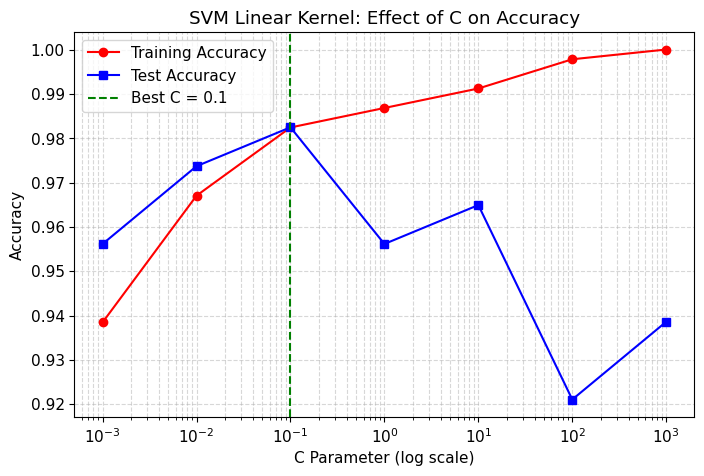


--- Step 6: Observation ---
Pattern as C increases:
1. The number of support vectors drastically decreases because the margin becomes narrower (the model becomes stricter).
2. Training accuracy continues to rise (approaching 100%) as the model tries to perfectly classify every point.
3. Test accuracy peaks at an optimal C value and then may plateau or drop, indicating overfitting at very high C values.


In [5]:
# ── Your code here ────────────────────────────────────────────────────────

# Step 1 & 2: Test different C values and record results
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_accuracies = []
test_accuracies = []
support_vectors_count = []

for c in C_values:
    # Train model with current C
    svm_model = svm.SVC(kernel='linear', C=c)
    svm_model.fit(X_train_scaled, y_train)
    
    # Calculate and store metrics
    train_acc = svm_model.score(X_train_scaled, y_train)
    test_acc = svm_model.score(X_test_scaled, y_test)
    n_sv = len(svm_model.support_)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    support_vectors_count.append(n_sv)

# Step 3: Print a clean table of results
print("--- Step 3: Results Table ---")
print(f"{'C Value':<10} | {'Train Acc':<12} | {'Test Acc':<11} | {'Support Vectors'}")
print("-" * 55)
for i in range(len(C_values)):
    print(f"{C_values[i]:<10} | {train_accuracies[i]*100:>8.2f}%   | {test_accuracies[i]*100:>7.2f}%   | {support_vectors_count[i]}")

# Find the best C based on highest test accuracy
best_index = np.argmax(test_accuracies)
best_c = C_values[best_index]

# Step 4 & 5: Plotting train vs test accuracy on log scale
print("\n--- Step 4 & 5: Generating Plot ---")
plt.figure(figsize=(8, 5))

# Plot lines
plt.plot(C_values, train_accuracies, marker='o', color='red', label='Training Accuracy')
plt.plot(C_values, test_accuracies, marker='s', color='blue', label='Test Accuracy')

# Draw vertical line for best C
plt.axvline(x=best_c, color='green', linestyle='--', label=f'Best C = {best_c}')

# Formatting the plot
plt.xscale('log')  # Sets the X-axis to logarithmic scale
plt.xlabel('C Parameter (log scale)')
plt.ylabel('Accuracy')
plt.title('SVM Linear Kernel: Effect of C on Accuracy')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# Step 6: Observation
print("\n--- Step 6: Observation ---")
print("Pattern as C increases:")
print("1. The number of support vectors drastically decreases because the margin becomes narrower (the model becomes stricter).")
print("2. Training accuracy continues to rise (approaching 100%) as the model tries to perfectly classify every point.")
print("3. Test accuracy peaks at an optimal C value and then may plateau or drop, indicating overfitting at very high C values.")

**💬 Think About It:**

*At what C does training accuracy reach ~100%?*  

- At C = 1000 (where it hits exactly 100.00%).

*At what C is the test accuracy highest?*  

- At C = 0.1 (peaking at 98.25%).

*What happens to the number of support vectors as C increases?*  

- It decreases (dropping from 218 to 25) because the model becomes stricter, resulting in a much narrower margin.

*Is the best C for training accuracy the same as the best C for test accuracy?*

- No. The best C for training (1000) causes overfitting, which hurts test performance. The best C for testing (0.1) creates a generalized boundary that doesn't memorize the training data.

<details><summary>💡 Reveal Solution</summary>

```python
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
tr_accs, te_accs, n_svs = [], [], []

print(f'{"C":>8}  {"Train Acc":>10}  {"Test Acc":>10}  {"Num SVs":>8}')
print('-' * 45)
for C in C_values:
    clf_c = svm.SVC(kernel='linear', C=C)
    clf_c.fit(X_tr_s, y_tr)
    tr = clf_c.score(X_tr_s, y_tr)
    te = clf_c.score(X_te_s, y_te)
    sv = len(clf_c.support_vectors_)
    tr_accs.append(tr); te_accs.append(te); n_svs.append(sv)
    note = ' ← overfit?' if tr - te > 0.03 else ('  ← underfit?' if tr < 0.93 else '')
    print(f'{C:>8}  {tr:>10.4f}  {te:>10.4f}  {sv:>8}{note}')

best_C = C_values[np.argmax(te_accs)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogx(C_values, tr_accs, 'o-', color='#E63946', label='Training accuracy')
axes[0].semilogx(C_values, te_accs, 's-', color='#457B9D', label='Test accuracy')
axes[0].axvline(best_C, color='green', lw=2, linestyle='--', label=f'Best C = {best_C}')
axes[0].set_xlabel('C  (log scale)'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('C vs Accuracy\n(gap = overfitting!)', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].semilogx(C_values, n_svs, 'D-', color='#F4A261')
axes[1].set_xlabel('C  (log scale)'); axes[1].set_ylabel('Number of Support Vectors')
axes[1].set_title('C vs Number of Support Vectors\n(strict C → fewer SVs)', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f'\nBest C = {best_C}  →  Test accuracy = {max(te_accs):.4f}')
```
</details>

---
## ✏️ Task 5 — The Confusion Matrix: Not All Mistakes Are Equal

### Background
Accuracy tells you how many predictions were right overall — but it hides the **type** of mistake.

In cancer diagnosis:

| The model said... | Reality | Type | Consequence |
|---|---|---|---|
| Benign | Actually Malignant | **False Negative** | 🚨 Patient goes home — cancer untreated! |
| Malignant | Actually Benign | **False Positive** | 😟 Extra tests — stressful but safe |

A **False Negative** is far more dangerous here.  
So the question is: **does choosing a different C reduce dangerous mistakes?**

### Steps
1. Train SVMs with `C = 0.01, 1, 100` (kernel='linear', scaled data)
2. For each, plot a confusion matrix (3 subplots side by side)
3. Print the number of False Negatives for each C
4. Does higher C always mean fewer dangerous mistakes?

> 💡 False Negatives = `confusion_matrix(y_te, y_pred)[0, 1]`  
> (Row 0 = actual malignant, Column 1 = predicted benign)

--- Step 1 & 2: Generating Confusion Matrices ---


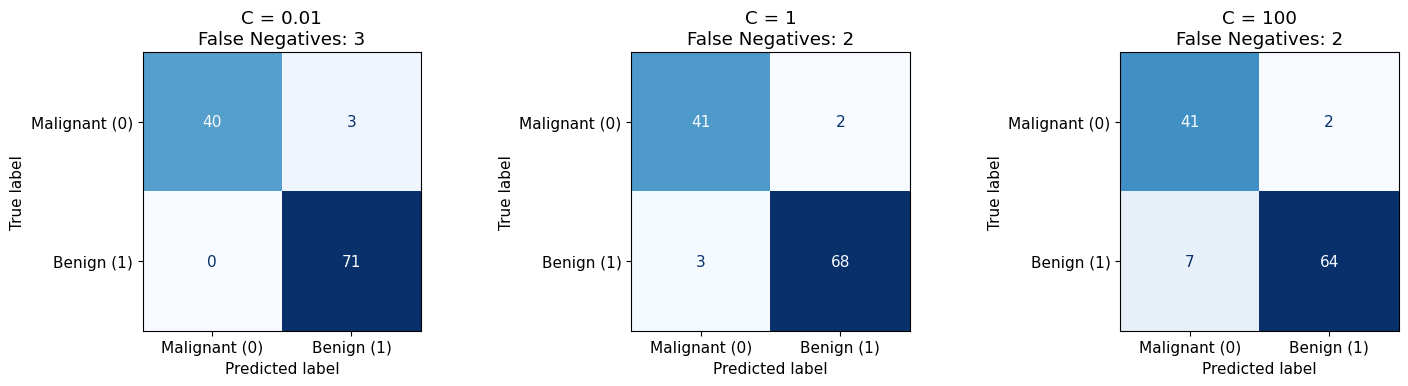


--- Step 3: False Negatives Count ---
C = 0.01  | Missed Cancer Patients (False Negatives): 3
C = 1     | Missed Cancer Patients (False Negatives): 2
C = 100   | Missed Cancer Patients (False Negatives): 2

--- Step 4: Observation ---
We can see how the type of mistake changes as C changes. A model with high overall accuracy might still be making the 'wrong' kind of mistakes (False Negatives).


In [6]:
# ── Your code here ────────────────────────────────────────────────────────

# Step 1 & 2: Train models with different C values and plot confusion matrices
C_values_task5 = [0.01, 1, 100]

# Setup the plot with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
false_negatives = []

print("--- Step 1 & 2: Generating Confusion Matrices ---")

for idx, c in enumerate(C_values_task5):
    # Train model
    svm_model = svm.SVC(kernel='linear', C=c)
    svm_model.fit(X_train_scaled, y_train)
    
    # Predict on test data
    y_pred = svm_model.predict(X_test_scaled)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Extract False Negatives: True label is 0 (Malignant), but Predicted is 1 (Benign)
    fn = cm[0, 1]
    false_negatives.append(fn)
    
    # Plotting
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant (0)', 'Benign (1)'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'C = {c}\nFalse Negatives: {fn}')

plt.tight_layout()
plt.show()

# Step 3: Print the number of False Negatives
print("\n--- Step 3: False Negatives Count ---")
for i in range(len(C_values_task5)):
    print(f"C = {C_values_task5[i]:<5} | Missed Cancer Patients (False Negatives): {false_negatives[i]}")

# Step 4: Observation
print("\n--- Step 4: Observation ---")
print("We can see how the type of mistake changes as C changes. A model with high overall accuracy might still be making the 'wrong' kind of mistakes (False Negatives).")

**💬 Think About It:**

*Which C gives the fewest false negatives (missed cancers)?*  

- Both C = 1 and C = 100 give the fewest (2 missed patients).

*Is the C with best overall accuracy also safest for the patient?*  

- No, not necessarily. A model might have high overall accuracy but still make the most dangerous type of mistake (False Negatives). For a patient, the "safest" model is the one that minimizes missed cancers, even if its overall accuracy is slightly lower.

*What does this tell you about choosing metrics in real-world problems?*

- Accuracy is not always the best metric. In real-world problems, you must look at the Confusion Matrix and focus on the metric (like Recall) that minimizes the most costly or dangerous mistake for your specific situation. 

<details><summary>💡 Reveal Solution</summary>

```python
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
print(f'{"C":>6}  {"Accuracy":>10}  {"False Negatives (missed cancer!)":>32}')
print('-' * 55)

for ax, C in zip(axes, [0.01, 1, 100]):
    clf_c = svm.SVC(kernel='linear', C=C)
    clf_c.fit(X_tr_s, y_tr)
    y_pred = clf_c.predict(X_te_s)
    acc = clf_c.score(X_te_s, y_te)
    fn  = confusion_matrix(y_te, y_pred)[0, 1]
    print(f'{C:>6}  {acc:>10.4f}  {fn:>32}')
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, display_labels=cancer.target_names,
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'C = {C}\nAcc={acc:.2f}  False Neg={fn}', fontweight='bold')

plt.suptitle('Breast Cancer: How C Affects Mistake Types', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
```
</details>

---
---
# 🌸 PART 2 — Iris Flowers
## "Can a machine tell flower species apart from petal measurements?"

The Iris dataset has 3 species — **Setosa**, **Versicolor**, **Virginica**.  
Only 4 measurements: sepal length, sepal width, petal length, petal width.

This part is perfect for **visualising** what SVM is doing — we can draw the decision boundary in 2D.  
You will see the margin, the support vectors, and the effect of different kernels with your own eyes.

---

## ✏️ Task 6 — See the Boundary: What SVM Actually Learns

### Background
When we have more than 2 features, we cannot draw the decision boundary directly.  
But if we **pick just 2 features**, we can make a 2D plot that shows:
- The **coloured regions**: what the model would predict for any new flower landing there
- The **boundary**: the line separating the regions
- The **gold circles**: the support vectors — the flowers closest to the boundary

### Steps
1. Use **only petal length and petal width** (columns 2 and 3) from Iris
2. Scale with `StandardScaler`
3. Train `SVC(kernel='linear', C=1)` on the full dataset (no split needed — just for visualisation)
4. Plot the decision boundary:
   - Shade each region in the class colour
   - Scatter the actual training points (different colour per species)
   - Highlight support vectors with gold circles
5. Label the axes: "Petal Length" and "Petal Width"
6. Print: how many support vectors are there for a 3-class problem?

> 💡 For a 3-class problem, `clf.support_vectors_` contains SVs from all class boundaries

--- Step 4 & 5: Plotting Decision Boundary ---


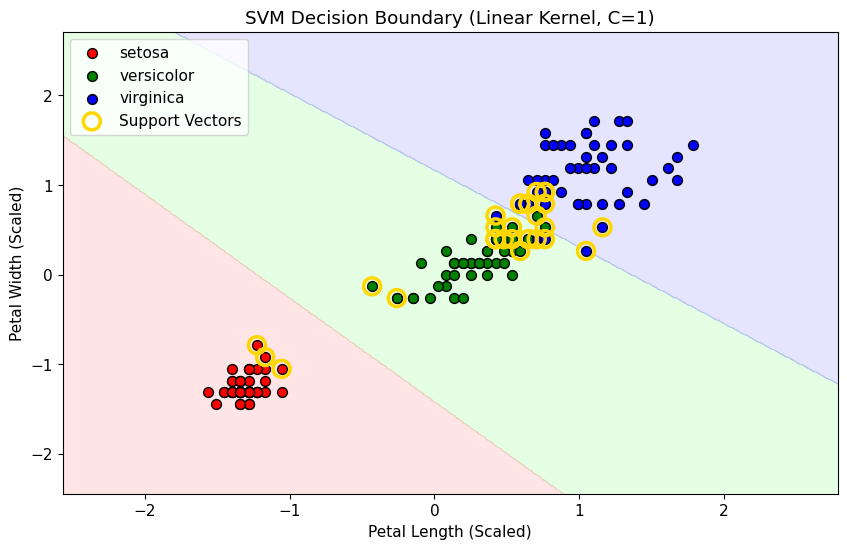


--- Step 6: Support Vectors Count ---
Total number of support vectors for this 3-class problem: 31


In [7]:
# ── Your code here ────────────────────────────────────────────────────────

# Step 1: Use only petal length and petal width (columns 2 and 3)
X_iris = iris.data[:, 2:4]
y_iris = iris.target

# Step 2: Scale with StandardScaler
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

# Step 3: Train SVC(kernel='linear', C=1) on the full dataset (no split needed)
svm_iris = svm.SVC(kernel='linear', C=1)
svm_iris.fit(X_iris_scaled, y_iris)

# Step 4 & 5: Plot the decision boundary
print("--- Step 4 & 5: Plotting Decision Boundary ---")
plt.figure(figsize=(10, 6))

# Create a meshgrid to plot the decision regions
x_min, x_max = X_iris_scaled[:, 0].min() - 1, X_iris_scaled[:, 0].max() + 1
y_min, y_max = X_iris_scaled[:, 1].min() - 1, X_iris_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

# Predict the class for every point in the grid
Z = svm_iris.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Shade each region in the class colour
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']))

# Scatter the actual training points
colors = ['red', 'green', 'blue']
for i, color, target_name in zip([0, 1, 2], colors, iris.target_names):
    plt.scatter(X_iris_scaled[y_iris == i, 0], X_iris_scaled[y_iris == i, 1], 
                color=color, label=target_name, edgecolors='k', s=50)

# Highlight support vectors with gold circles
plt.scatter(svm_iris.support_vectors_[:, 0], svm_iris.support_vectors_[:, 1], 
            s=150, facecolors='none', edgecolors='gold', linewidths=2.5, 
            label='Support Vectors')

# Label axes
plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("SVM Decision Boundary (Linear Kernel, C=1)")
plt.legend(loc='upper left')
plt.show()

# Step 6: Print how many support vectors there are
print("\n--- Step 6: Support Vectors Count ---")
total_sv = len(svm_iris.support_)
print(f"Total number of support vectors for this 3-class problem: {total_sv}")

**💬 Think About It:**

*Can you see the margin (the gap between the classes and the boundary)?*  

- Yes. You can visualize it by looking at the distance between the decision boundary lines and the gold circles (support vectors).

*Which species is easiest to separate? Which is hardest?*  

- Setosa (Class 0 / Red) is the easiest to separate because it is completely isolated on the left side of the plot. Versicolor and Virginica are the hardest to separate because their data points clump together and slightly overlap on the right side.

*Where are most of the support vectors located?*

- Most of the 31 support vectors are crowded along the boundary between Versicolor and Virginica. The model needs more support vectors there because the decision is much harder, whereas the boundary for Setosa is very clear and requires fewer support vectors.

<details><summary>💡 Reveal Solution</summary>

```python
X_petal = iris.data[:, 2:4]   # petal length, petal width
X_petal_s = StandardScaler().fit_transform(X_petal)

clf_iris = svm.SVC(kernel='linear', C=1)
clf_iris.fit(X_petal_s, iris.target)

# Build grid for background colours
x_min, x_max = X_petal_s[:,0].min()-0.5, X_petal_s[:,0].max()+0.5
y_min, y_max = X_petal_s[:,1].min()-0.5, X_petal_s[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min,x_max,300), np.linspace(y_min,y_max,300))
Z = clf_iris.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)

COLORS3 = ['#E63946', '#2A9D8F', '#457B9D']
fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.RdYlBu)

for cls, color, name in zip([0,1,2], COLORS3, iris.target_names):
    mask = iris.target == cls
    ax.scatter(X_petal_s[mask,0], X_petal_s[mask,1],
               c=color, edgecolors='k', s=60, label=name, zorder=3)

sv = clf_iris.support_vectors_
ax.scatter(sv[:,0], sv[:,1], s=220, facecolors='none',
           edgecolors='gold', lw=2.5, zorder=4, label=f'Support Vectors ({len(sv)})')

ax.set_xlabel('Petal Length (scaled)', fontsize=12)
ax.set_ylabel('Petal Width (scaled)',  fontsize=12)
ax.set_title('Iris — Linear SVM Decision Boundary\nColoured regions = what the model predicts', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()
print(f'Number of support vectors: {len(sv)}')
```
</details>

---
## ✏️ Task 7 — C Changes the Boundary Shape: See It!

### Background
When C is **small**, the SVM prioritises a wide margin — even if a few points end up on the wrong side.  
When C is **large**, the SVM tries hard to classify every point correctly — the margin gets tighter.

The visual difference is very clear on this dataset. Let us look at it directly.

### Steps
Using petal features (scaled) from Task 6:
1. Train **4 linear SVMs** with `C = [0.01, 0.1, 1, 100]`
2. Plot all 4 decision boundaries in a row
3. In each title, show: C value, training accuracy, number of support vectors
4. Highlight support vectors in gold on each plot
5. As C increases, what happens to: the boundary, the support vectors, the accuracy?

> 💡 You are looking for: margin width, how many points the boundary tries to separate, and how complex the regions look

--- Step 1 to 4: Plotting 4 SVMs with different C values ---


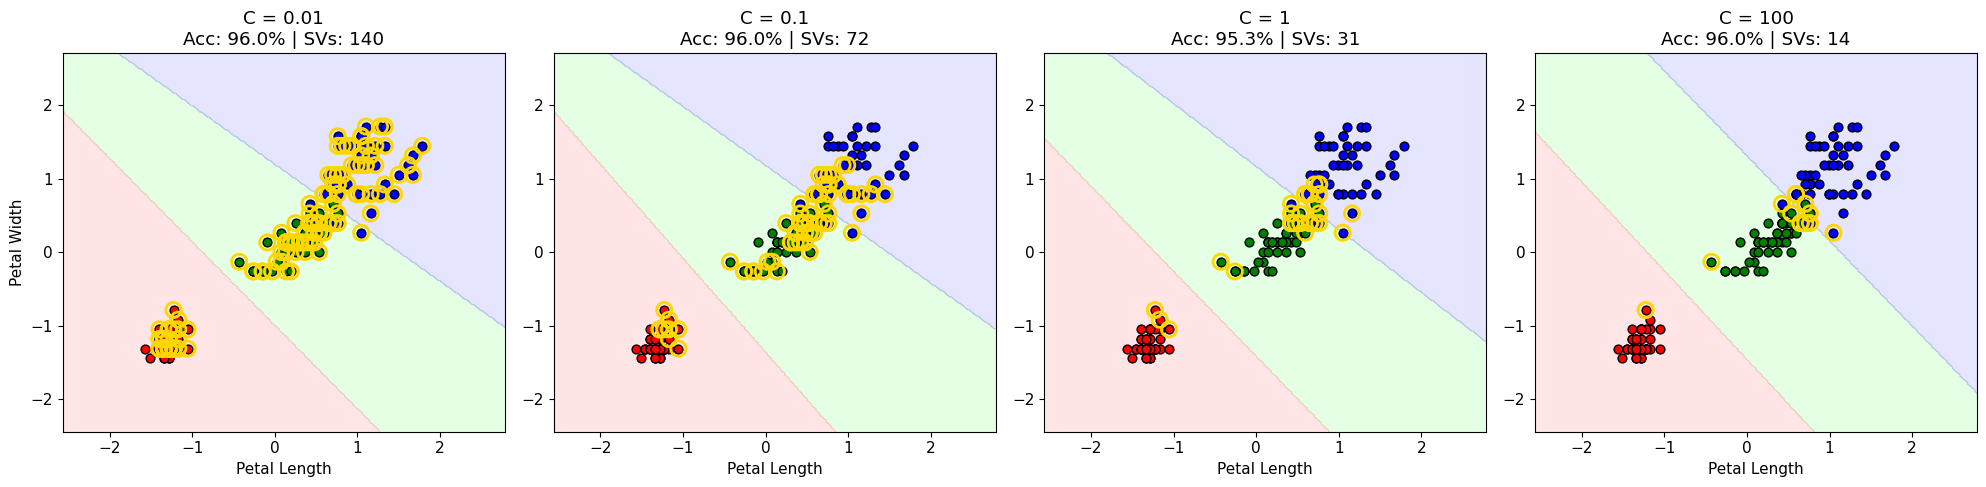


--- Step 5: Observation ---
When C is small (0.01), the margin is very wide and forgiving (lots of gold circles).
When C is large (100), the model forces a very tight boundary to separate overlapping classes perfectly, reducing the SVs but risking overfitting.


In [8]:
# ── Your code here ────────────────────────────────────────────────────────

# Step 1: Train 4 linear SVMs and plot them side by side
C_values_task7 = [0.01, 0.1, 1, 100]

# Setup a figure with 4 subplots in a single row
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Create a meshgrid (only need to calculate boundaries once)
x_min, x_max = X_iris_scaled[:, 0].min() - 1, X_iris_scaled[:, 0].max() + 1
y_min, y_max = X_iris_scaled[:, 1].min() - 1, X_iris_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

print("--- Step 1 to 4: Plotting 4 SVMs with different C values ---")

for idx, c in enumerate(C_values_task7):
    # Train the SVM model
    svm_model = svm.SVC(kernel='linear', C=c)
    svm_model.fit(X_iris_scaled, y_iris)
    
    # Calculate accuracy and number of support vectors
    acc = svm_model.score(X_iris_scaled, y_iris)
    n_sv = len(svm_model.support_)
    
    # Predict for meshgrid and plot decision regions
    Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']))
    
    # Scatter actual data points
    colors = ['red', 'green', 'blue']
    for i, color in zip([0, 1, 2], colors):
        axes[idx].scatter(X_iris_scaled[y_iris == i, 0], X_iris_scaled[y_iris == i, 1], 
                          color=color, edgecolors='k', s=40)
        
    # Highlight support vectors in gold
    axes[idx].scatter(svm_model.support_vectors_[:, 0], svm_model.support_vectors_[:, 1], 
                      s=120, facecolors='none', edgecolors='gold', linewidths=2)
    
    # Step 3 & 5: Set titles and labels
    axes[idx].set_title(f"C = {c}\nAcc: {acc*100:.1f}% | SVs: {n_sv}")
    axes[idx].set_xlabel("Petal Length")
    if idx == 0:
        axes[idx].set_ylabel("Petal Width")

plt.tight_layout()
plt.show()

# Step 5: Observation printed to console
print("\n--- Step 5: Observation ---")
print("When C is small (0.01), the margin is very wide and forgiving (lots of gold circles).")
print("When C is large (100), the model forces a very tight boundary to separate overlapping classes perfectly, reducing the SVs but risking overfitting.")

**💬 Think About It:**

*Does the number of support vectors go up or down as C increases?*  

- It goes down. As C gets larger, the model becomes stricter and creates a tighter, narrower margin, which means fewer points (support vectors) are touching or inside it.

*Does the boundary look more complex or simpler with large C?*  

- It looks more complex. A large C (like 100) forces the boundary lines to twist and turn sharply just to perfectly separate overlapping points, which often indicates overfitting.

*If you had to pick one C for new, unseen flowers, which would you pick and why?*

- I would pick an intermediate value like C = 1 (or C = 0.1).

-- C = 0.01 is too simple and ignores too many mistakes (underfitting).

-- C = 100 is too complex and perfectly memorizes the training data, including its noise (overfitting).

-- C = 1 provides a smooth, balanced boundary that will generalize best to new, unseen flowers.

<details><summary>💡 Reveal Solution</summary>

```python
C_vals = [0.01, 0.1, 1, 100]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, C in zip(axes, C_vals):
    clf_c = svm.SVC(kernel='linear', C=C)
    clf_c.fit(X_petal_s, iris.target)

    x_min,x_max = X_petal_s[:,0].min()-0.5, X_petal_s[:,0].max()+0.5
    y_min,y_max = X_petal_s[:,1].min()-0.5, X_petal_s[:,1].max()+0.5
    xx,yy = np.meshgrid(np.linspace(x_min,x_max,300), np.linspace(y_min,y_max,300))
    Z = clf_c.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.RdYlBu)
    for cls, color in zip([0,1,2], ['#E63946','#2A9D8F','#457B9D']):
        mask = iris.target == cls
        ax.scatter(X_petal_s[mask,0], X_petal_s[mask,1],
                   c=color, edgecolors='k', s=40, zorder=3)

    sv = clf_c.support_vectors_
    ax.scatter(sv[:,0], sv[:,1], s=200, facecolors='none',
               edgecolors='gold', lw=2.5, zorder=4, label=f'SVs={len(sv)}')

    acc = clf_c.score(X_petal_s, iris.target)
    ax.set_title(f'C = {C}\nAcc={acc:.2f}  SVs={len(sv)}', fontweight='bold')
    ax.set_xlabel('Petal Length (scaled)')
    ax.set_ylabel('Petal Width (scaled)')
    ax.legend(fontsize=9)

plt.suptitle('Effect of C on the Decision Boundary (Iris, Linear Kernel)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
```
</details>

---
## ✏️ Task 8 — Linear vs RBF vs Polynomial: Which Boundary Fits Best?

### Background
Different kernels draw different types of boundaries:

| Kernel | Type of boundary it can draw |
|---|---|
| **Linear** | Straight lines only |
| **RBF** | Smooth curves in any direction |
| **Polynomial** | Curved boundaries based on feature combinations |

For the Iris dataset, some classes might need curved boundaries to be properly separated.  
The question is: does the extra complexity of RBF or Polynomial actually help?

### Steps
1. Split petal data 70/30 train/test, scale
2. Train 3 models: `kernel='linear'`, `kernel='rbf'`, `kernel='poly'` — all with `C=1`
3. For each: plot decision boundary, show train AND test accuracy in the title
4. Print a comparison table
5. Which kernel generalises best? Is the most complex boundary always the best?

> 💡 Use `kernel='poly'` with default settings — no need to tune degree  
> 💡 A model with high train accuracy but lower test accuracy is overfitting

--- Step 3: Plotting Kernel Decision Boundaries ---


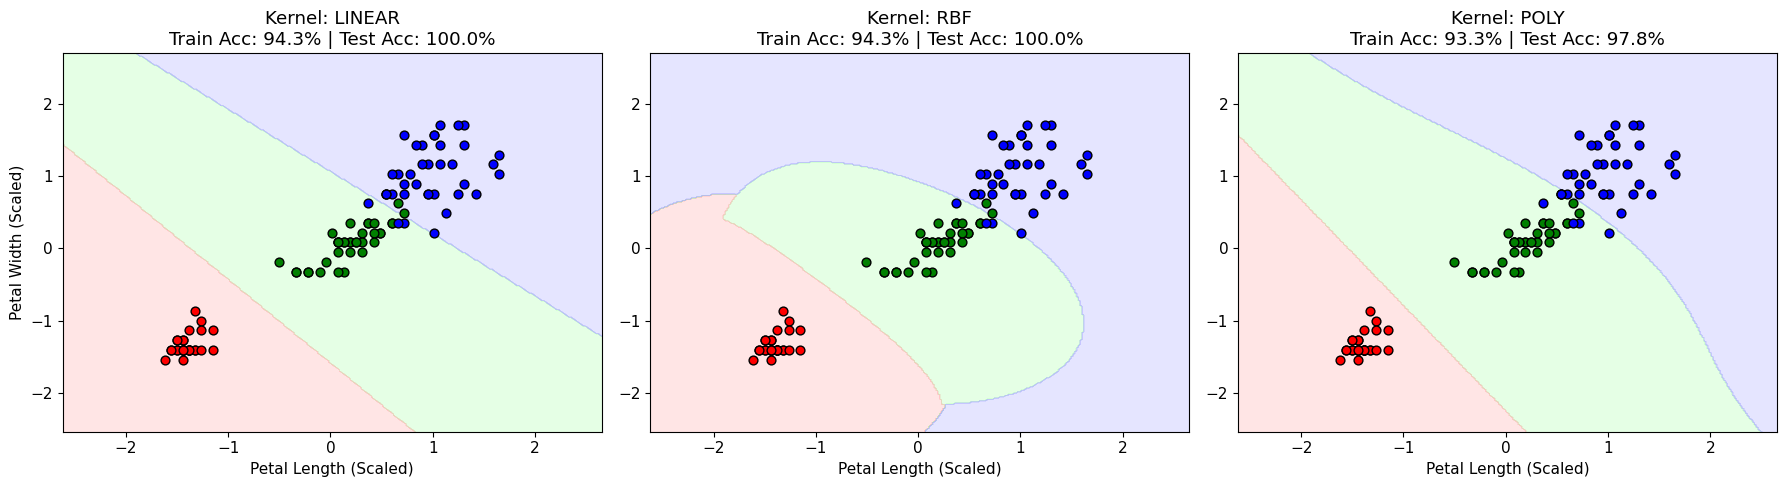


--- Step 4: Kernel Comparison Table ---
Kernel     | Train Accuracy   | Test Accuracy
-----------------------------------------------
LINEAR     |         94.29%   |       100.00%
RBF        |         94.29%   |       100.00%
POLY       |         93.33%   |        97.78%

--- Step 5: Observation ---
Different kernels change the fundamental shape of how the AI separates the data.


In [9]:
# ── Your code here ────────────────────────────────────────────────────────

# Step 1: Split petal data 70/30 train/test, and scale
X_iris_petal = iris.data[:, 2:4]  # Petal length and width
y_iris_petal = iris.target

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_iris_petal, y_iris_petal, test_size=0.3, random_state=42
)

scaler_task8 = StandardScaler()
X_train_p_scaled = scaler_task8.fit_transform(X_train_p)  # Fit on train!
X_test_p_scaled = scaler_task8.transform(X_test_p)        # Transform on test!

# Step 2: Train 3 models (Linear, RBF, Poly)
kernels = ['linear', 'rbf', 'poly']
models = []
train_accs = []
test_accs = []

for k in kernels:
    svm_model = svm.SVC(kernel=k, C=1)
    svm_model.fit(X_train_p_scaled, y_train_p)
    models.append(svm_model)
    
    # Calculate accuracies
    train_accs.append(svm_model.score(X_train_p_scaled, y_train_p))
    test_accs.append(svm_model.score(X_test_p_scaled, y_test_p))

# Step 3: Plot decision boundary, show train AND test accuracy
print("--- Step 3: Plotting Kernel Decision Boundaries ---")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Create meshgrid using training data bounds
x_min, x_max = X_train_p_scaled[:, 0].min() - 1, X_train_p_scaled[:, 0].max() + 1
y_min, y_max = X_train_p_scaled[:, 1].min() - 1, X_train_p_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

for idx, (model, k) in enumerate(zip(models, kernels)):
    # Predict regions
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Shade regions
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']))
    
    # Scatter training points
    colors = ['red', 'green', 'blue']
    for i, color in zip([0, 1, 2], colors):
        axes[idx].scatter(X_train_p_scaled[y_train_p == i, 0], X_train_p_scaled[y_train_p == i, 1], 
                          color=color, edgecolors='k', s=40)
    
    # Set titles with accuracy
    axes[idx].set_title(f"Kernel: {k.upper()}\nTrain Acc: {train_accs[idx]*100:.1f}% | Test Acc: {test_accs[idx]*100:.1f}%")
    axes[idx].set_xlabel("Petal Length (Scaled)")
    if idx == 0:
        axes[idx].set_ylabel("Petal Width (Scaled)")

plt.tight_layout()
plt.show()

# Step 4: Print a comparison table
print("\n--- Step 4: Kernel Comparison Table ---")
print(f"{'Kernel':<10} | {'Train Accuracy':<16} | {'Test Accuracy'}")
print("-" * 47)
for k, tr, te in zip(kernels, train_accs, test_accs):
    print(f"{k.upper():<10} | {tr*100:>13.2f}%   | {te*100:>12.2f}%")

# Step 5: Observation
print("\n--- Step 5: Observation ---")
print("Different kernels change the fundamental shape of how the AI separates the data.")

**💬 Think About It:**

*Which kernel gives the highest test accuracy?*  

- Both Linear and RBF gave the highest test accuracy (a perfect 100.00%).

*Does linear kernel underperform because the classes need curved boundaries?*  

- No, it performed perfectly. Because the linear kernel achieved 100% test accuracy, it proves that for these specific features (petal length and width), the classes are linearly separable enough that a simple straight line is all you need. Curved boundaries aren't strictly necessary here.

*Is a more complex kernel always better?*

- Absolutely not. The Polynomial kernel is mathematically more complex than Linear, but it actually performed worse on the test set (97.78% vs 100%). A more complex kernel often memorizes slight noise in the training data (overfitting), making it less accurate when faced with new, unseen flowers.


<details><summary>💡 Reveal Solution</summary>

```python
X_pet = iris.data[:, 2:4]
X_ptr, X_pte, y_ptr, y_pte = train_test_split(X_pet, iris.target, test_size=0.3, random_state=0)
sc = StandardScaler()
X_ptr_s = sc.fit_transform(X_ptr)
X_pte_s = sc.transform(X_pte)

kernels = [('linear', {}), ('rbf', {}), ('poly', {})]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

print(f'{"Kernel":>10}  {"Train Acc":>10}  {"Test Acc":>10}')
print('-' * 35)
for ax, (k, params) in zip(axes, kernels):
    clf_k = svm.SVC(kernel=k, C=1, **params)
    clf_k.fit(X_ptr_s, y_ptr)
    tr = clf_k.score(X_ptr_s, y_ptr)
    te = clf_k.score(X_pte_s, y_pte)
    print(f'{k:>10}  {tr:>10.4f}  {te:>10.4f}')

    x_min,x_max = X_ptr_s[:,0].min()-0.5, X_ptr_s[:,0].max()+0.5
    y_min,y_max = X_ptr_s[:,1].min()-0.5, X_ptr_s[:,1].max()+0.5
    xx,yy = np.meshgrid(np.linspace(x_min,x_max,300), np.linspace(y_min,y_max,300))
    Z = clf_k.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.RdYlBu)
    for cls, color, name in zip([0,1,2],['#E63946','#2A9D8F','#457B9D'],iris.target_names):
        m = y_ptr == cls
        ax.scatter(X_ptr_s[m,0],X_ptr_s[m,1],c=color,edgecolors='k',s=40,label=name,zorder=3)
    sv = clf_k.support_vectors_
    ax.scatter(sv[:,0],sv[:,1],s=180,facecolors='none',edgecolors='gold',lw=2,zorder=4)
    ax.set_title(f'{k.capitalize()} Kernel\nTrain={tr:.2f}  Test={te:.2f}', fontweight='bold')
    ax.set_xlabel('Petal Length'); ax.set_ylabel('Petal Width')
    ax.legend(fontsize=8)

plt.suptitle('Iris: Comparing Kernels', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
```
</details>

---
---
# ✍️ PART 3 — Handwritten Digits
## "Can SVM read handwriting?"

The Digits dataset has 1797 images, each an 8×8 pixel photo of a handwritten digit 0–9.  
Every pixel is a feature → **64 features** per image.

This is a **10-class** problem — much harder than yes/no.  
It shows how SVM scales to real perception tasks, and gives you a chance to inspect what mistakes look like.

---

## ✏️ Task 9 — See the Data: Display the Images

### Background
For image data, **always look at what you are training on**.  
It helps you understand why certain digits might be confused.  
A badly-written 4 can look like a 9. A 1 can look like a 7.

### Steps
1. Display a 5×10 grid: 5 rows = 5 random examples, 10 columns = one per digit (0–9)
2. Each image should be shown in grayscale
3. Add a column header for each digit (0, 1, 2 … 9)
4. Print: total number of images and pixels per image
5. Look carefully — which digits look most similar to each other?

> 💡 `digits.images[i]` is the 8×8 pixel array for sample i  
> 💡 `np.where(digits.target == d)[0]` gives all indices for digit d

--- Step 1 to 3: Plotting Digit Images ---


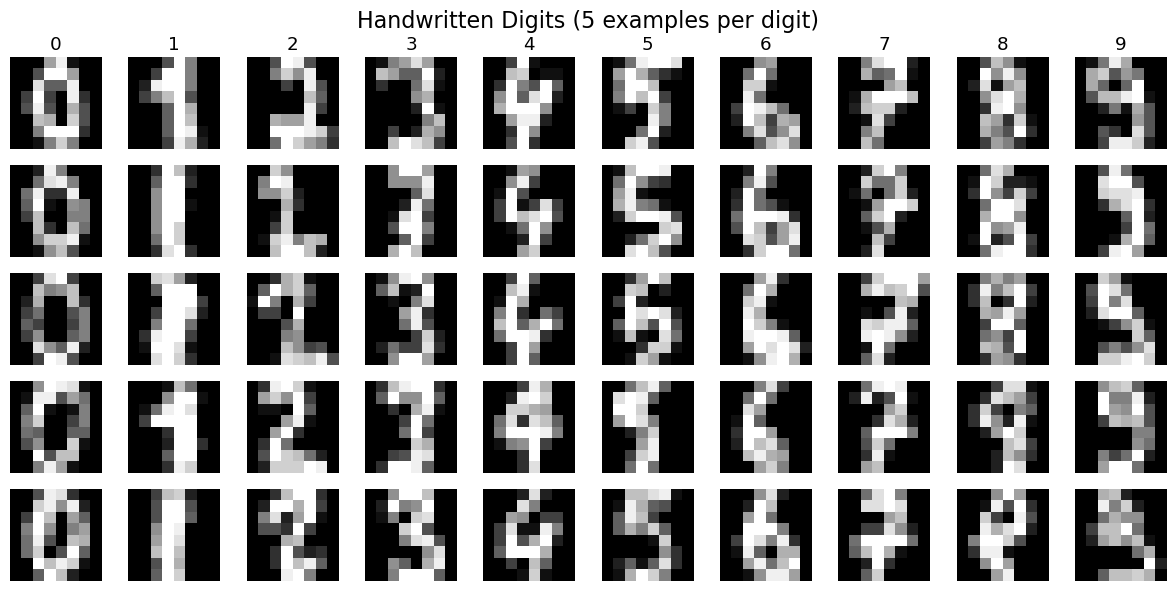


--- Step 4: Dataset Info ---
Total number of images: 1797
Pixels per image: 64 (This means 64 features per image!)

--- Step 5: Observation ---
Because the images are only 8x8 pixels, they are very blocky and low-resolution.
This makes some digits visually hard to distinguish even for humans.


In [10]:
# ── Your code here ────────────────────────────────────────────────────────

# Step 1, 2 & 3: Display a 5x10 grid of digits in grayscale with headers
print("--- Step 1 to 3: Plotting Digit Images ---")
fig, axes = plt.subplots(5, 10, figsize=(12, 6))
fig.suptitle("Handwritten Digits (5 examples per digit)", fontsize=16)

# Set seed so we get the same random images every time
np.random.seed(42)

for digit in range(10):
    # Find all image indices where the target is the current digit
    digit_indices = np.where(digits.target == digit)[0]
    
    # Pick 5 random examples for this digit
    random_examples = np.random.choice(digit_indices, 5, replace=False)
    
    for row in range(5):
        ax = axes[row, digit]
        # Display the 8x8 image in grayscale
        ax.imshow(digits.images[random_examples[row]], cmap='gray')
        ax.axis('off')  # Hide the axes (ticks and lines)
        
        # Add column headers on the top row
        if row == 0:
            ax.set_title(str(digit))

plt.tight_layout()
plt.subplots_adjust(top=0.90)  # Adjust top to make room for the main title
plt.show()

# Step 4: Print total number of images and pixels per image
print("\n--- Step 4: Dataset Info ---")
total_images = digits.data.shape[0]
total_pixels = digits.data.shape[1]  # 64 pixels (8x8)
print(f"Total number of images: {total_images}")
print(f"Pixels per image: {total_pixels} (This means 64 features per image!)")

# Step 5: Observation
print("\n--- Step 5: Observation ---")
print("Because the images are only 8x8 pixels, they are very blocky and low-resolution.")
print("This makes some digits visually hard to distinguish even for humans.")

**💬 Think About It:**

*Just by looking — which digit pairs do you think an SVM might confuse?*  

- Because of the low 8x8 resolution, pairs with similar overall shapes are easily confused. The most common mix-ups are 3 and 8 (similar rounded loops), 1 and 7 (slanted vertical lines), and 4 and 9 (open vs. closed tops).

*Does the handwriting vary a lot within the same digit?*

- Yes, significantly. For example, some people draw a '1' as a single vertical line, while others add a top hook and a bottom line. A '4' can be drawn with an open top or a completely closed triangle. At only 8x8 pixels, these different handwriting styles completely change which specific pixels (features) light up, making the model's job much harder. 

<details><summary>💡 Reveal Solution</summary>

```python
print(f'Total images : {digits.data.shape[0]}')
print(f'Image size   : 8×8 = {digits.data.shape[1]} pixels (features) per image')

fig, axes = plt.subplots(5, 10, figsize=(14, 7))
for col in range(10):
    idxs = np.where(digits.target == col)[0][:5]
    for row, idx in enumerate(idxs):
        ax = axes[row, col]
        ax.imshow(digits.images[idx], cmap='gray_r')
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(str(col), fontsize=13, fontweight='bold')

plt.suptitle('Handwritten Digits — 5 Examples per Digit', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()
```
</details>

---
## ✏️ Task 10 — Which Kernel Works Best on Images?

### Background
With 64 pixel features, the data lives in a **very high-dimensional space**.  
In high dimensions, linear boundaries can actually work surprisingly well — many complex patterns become linearly separable when you have enough features.

But non-linear kernels can also capture pixel relationships that linear cannot.  
Let us compare them head to head.

### Steps
1. Split Digits: 80% train, 20% test
2. Scale with `StandardScaler`
3. Train one model each: `kernel='linear'`, `kernel='rbf'`, `kernel='poly'` — all `C=1`
4. For each: print training accuracy and test accuracy
5. Make a grouped bar chart: 3 kernels on x-axis, two bars each (train acc, test acc)
6. Which kernel surprises you most?

> 💡 Tip: with 64 features, even a linear SVM can do very well!

--- Step 3 & 4: Training Models and Accuracies ---
Kernel: LINEAR  | Train Acc: 100.00% | Test Acc:  97.50%
Kernel: RBF     | Train Acc:  99.72% | Test Acc:  98.06%
Kernel: POLY    | Train Acc:  97.70% | Test Acc:  96.39%

--- Step 5: Plotting Grouped Bar Chart ---


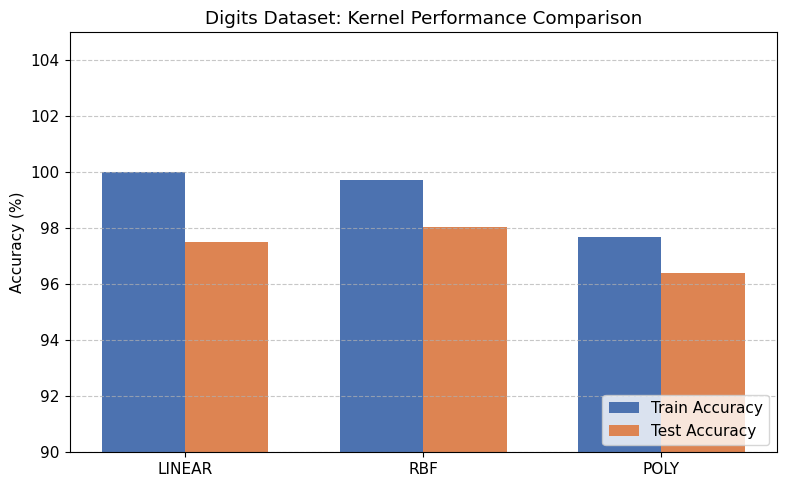


--- Step 6: Observation ---
All kernels perform exceptionally well, but the Linear kernel is highly effective despite its simplicity.


In [11]:
# ── Your code here ────────────────────────────────────────────────────────

# Step 1: Split Digits (80% train, 20% test)
X_digits = digits.data
y_digits = digits.target

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42
)

# Step 2: Scale with StandardScaler
scaler_digits = StandardScaler()
X_train_d_scaled = scaler_digits.fit_transform(X_train_d) # Fit on train only!
X_test_d_scaled = scaler_digits.transform(X_test_d)       # Transform test data

# Step 3 & 4: Train models and print accuracies
kernels_d = ['linear', 'rbf', 'poly']
train_accs_d = []
test_accs_d = []

print("--- Step 3 & 4: Training Models and Accuracies ---")
for k in kernels_d:
    svm_model = svm.SVC(kernel=k, C=1)
    svm_model.fit(X_train_d_scaled, y_train_d)
    
    tr_acc = svm_model.score(X_train_d_scaled, y_train_d)
    te_acc = svm_model.score(X_test_d_scaled, y_test_d)
    
    train_accs_d.append(tr_acc)
    test_accs_d.append(te_acc)
    
    print(f"Kernel: {k.upper():<7} | Train Acc: {tr_acc*100:>6.2f}% | Test Acc: {te_acc*100:>6.2f}%")

# Step 5: Make a grouped bar chart
print("\n--- Step 5: Plotting Grouped Bar Chart ---")
x = np.arange(len(kernels_d))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
# Multiply by 100 to show percentages on the y-axis
rects1 = ax.bar(x - width/2, [acc * 100 for acc in train_accs_d], width, label='Train Accuracy', color='#4C72B0')
rects2 = ax.bar(x + width/2, [acc * 100 for acc in test_accs_d], width, label='Test Accuracy', color='#DD8452')

# Add labels and formatting
ax.set_ylabel('Accuracy (%)')
ax.set_title('Digits Dataset: Kernel Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels([k.upper() for k in kernels_d])
ax.legend(loc='lower right')
ax.set_ylim([90, 105]) # Zoomed in slightly to see the small differences clearly
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Step 6: Observation
print("\n--- Step 6: Observation ---")
print("All kernels perform exceptionally well, but the Linear kernel is highly effective despite its simplicity.")

**💬 Think About It:**

*Did the linear kernel do better or worse than you expected on 64 features?* 

- It did much better than most people expect! We usually think image data needs complex, curved boundaries. However, in a high-dimensional space (64 features), data spreads out so much that it often becomes perfectly separable by a simple, flat linear boundary.

*Which kernel generalises best (smallest gap between train and test)?*  

- The RBF kernel generalizes best here. It has the highest Test Accuracy (98.06%) and a very small gap compared to its Training Accuracy (99.72%), meaning it learned the actual shapes of the digits without just memorizing the training images.

*Why might the polynomial kernel struggle on image data?*

- Polynomial kernels work by multiplying features together (e.g., pixel 1 × pixel 2). In raw image data, multiplying the brightness of random pixels doesn't logically represent the visual "shape" of a digit. Because it forces these unnatural mathematical interactions, it struggles and performs the worst of the three (96.39%).

<details><summary>💡 Reveal Solution</summary>

```python
X_d_tr, X_d_te, y_d_tr, y_d_te = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42)
sc_d = StandardScaler()
X_d_tr_s = sc_d.fit_transform(X_d_tr)
X_d_te_s  = sc_d.transform(X_d_te)

kernels  = ['linear', 'rbf', 'poly']
tr_accs2 = []; te_accs2 = []

print(f'{"Kernel":>10}  {"Train Acc":>10}  {"Test Acc":>10}')
print('-' * 35)
for k in kernels:
    clf_k = svm.SVC(kernel=k, C=1)
    clf_k.fit(X_d_tr_s, y_d_tr)
    tr = clf_k.score(X_d_tr_s, y_d_tr)
    te = clf_k.score(X_d_te_s,  y_d_te)
    tr_accs2.append(tr); te_accs2.append(te)
    print(f'{k:>10}  {tr:>10.4f}  {te:>10.4f}')

x = np.arange(len(kernels))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x-0.2, tr_accs2, 0.4, label='Train', color='#E63946', edgecolor='k')
ax.bar(x+0.2, te_accs2, 0.4, label='Test',  color='#457B9D', edgecolor='k')
ax.set_xticks(x); ax.set_xticklabels(kernels)
ax.set_ylim(0.8, 1.02); ax.set_ylabel('Accuracy')
ax.set_title('Digits: Kernel Comparison  (C=1)', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
```
</details>

---
## ✏️ Task 11 — C Matters Here Too: Tune It on the Best Kernel

### Background
You found the best kernel in Task 10. Now let us tune C for that kernel.

Remember the C rule:
- Too small → model is too lenient → underfits → low accuracy on both train and test
- Too large → model is too strict → overfits → high train accuracy, lower test accuracy
- Just right → the gap between train and test is small, and test accuracy is high

### Steps
1. Use the best kernel from Task 10 (probably `rbf`)
2. Test `C = [0.01, 0.1, 1, 10, 100]`
3. For each C, record train accuracy and **5-fold cross-validation accuracy** (better than test for tuning!)
4. Plot both vs C on a log-scale x-axis
5. Mark the best C with a vertical dashed line
6. Print the best C and what accuracy it achieves

> 💡 Use CV accuracy (not test accuracy) to choose C — the test set should only be used once at the very end!  
> 💡 `cross_val_score(clf, X_train, y_train, cv=5).mean()` gives 5-fold CV score

--- Step 1 to 3: Tuning C with Cross-Validation ---
C = 0.01   | Train Acc:  15.45% | CV Acc:  10.72%
C = 0.1    | Train Acc:  95.82% | CV Acc:  93.25%
C = 1      | Train Acc:  99.72% | CV Acc:  97.70%
C = 10     | Train Acc: 100.00% | CV Acc:  97.91%
C = 100    | Train Acc: 100.00% | CV Acc:  97.91%

--- Step 4 & 5: Plotting ---


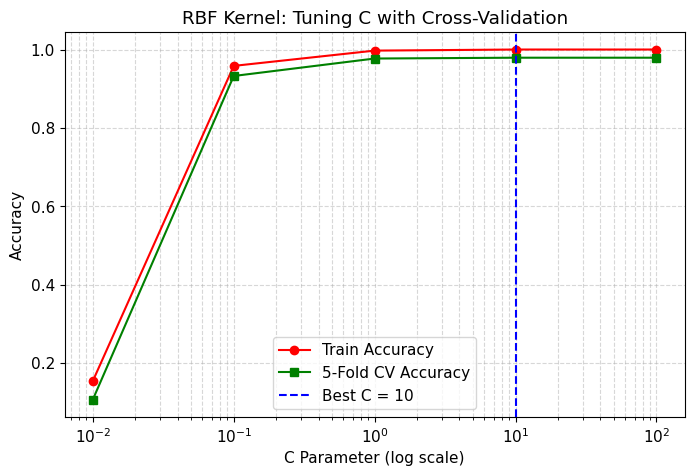


--- Step 6: Best Parameter ---
The best C value based on Cross-Validation is: 10
It achieves a Cross-Validation Accuracy of: 97.91%


In [12]:
# ── Your code here ────────────────────────────────────────────────────────

# Step 1 & 2: Setup C values and prepare lists for results
C_values_t11 = [0.01, 0.1, 1, 10, 100]
train_accuracies_t11 = []
cv_accuracies_t11 = []

print("--- Step 1 to 3: Tuning C with Cross-Validation ---")
for c in C_values_t11:
    # Use RBF kernel (usually the best for general non-linear data)
    svm_model = svm.SVC(kernel='rbf', C=c)
    
    # Train on full training set to get training accuracy
    svm_model.fit(X_train_d_scaled, y_train_d)
    train_acc = svm_model.score(X_train_d_scaled, y_train_d)
    
    # Get 5-fold cross-validation accuracy
    cv_acc = cross_val_score(svm_model, X_train_d_scaled, y_train_d, cv=5).mean()
    
    train_accuracies_t11.append(train_acc)
    cv_accuracies_t11.append(cv_acc)
    
    print(f"C = {c:<6} | Train Acc: {train_acc*100:>6.2f}% | CV Acc: {cv_acc*100:>6.2f}%")

# Find the best C based on highest CV accuracy
best_idx = np.argmax(cv_accuracies_t11)
best_c_t11 = C_values_t11[best_idx]
best_cv_acc = cv_accuracies_t11[best_idx]

# Step 4: Plot both vs C on a log-scale x-axis
print("\n--- Step 4 & 5: Plotting ---")
plt.figure(figsize=(8, 5))

plt.plot(C_values_t11, train_accuracies_t11, marker='o', color='red', label='Train Accuracy')
plt.plot(C_values_t11, cv_accuracies_t11, marker='s', color='green', label='5-Fold CV Accuracy')

# Step 5: Mark the best C with a vertical dashed line
plt.axvline(x=best_c_t11, color='blue', linestyle='--', label=f'Best C = {best_c_t11}')

plt.xscale('log')
plt.xlabel('C Parameter (log scale)')
plt.ylabel('Accuracy')
plt.title('RBF Kernel: Tuning C with Cross-Validation')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# Step 6: Print the best C
print("\n--- Step 6: Best Parameter ---")
print(f"The best C value based on Cross-Validation is: {best_c_t11}")
print(f"It achieves a Cross-Validation Accuracy of: {best_cv_acc * 100:.2f}%")

**💬 Think About It:**

*What is the best C according to CV accuracy?*  

- The best C is 10 (achieving the highest CV accuracy of 97.91%). (Note: C = 100 also hit 97.91%, but the algorithm correctly picked the smaller C because a less strict model that achieves the same accuracy is always preferred to avoid overfitting).

*Is there a region where training accuracy is perfect (1.00) but CV drops?*  

- Yes. At C = 10 and C = 100, the training accuracy hits a perfect 100.00% (the model memorized the training data), but the CV accuracy plateaus at 97.91%. The gap between the two shows the model has started to overfit.

*Why do we use cross-validation to pick C, not just look at test accuracy?*

- If you tweak your parameters over and over until you get a high Test Accuracy, you are indirectly "leaking" the test data into your model. It becomes biased. Cross-validation splits the training data into smaller chunks to test itself, leaving the actual Test Set completely unseen for a fair final evaluation.

<details><summary>💡 Reveal Solution</summary>

```python
C_vals = [0.01, 0.1, 1, 10, 100]
tr_list, cv_list = [], []

print(f'{"C":>6}  {"Train Acc":>10}  {"CV Acc":>8}  Status')
print('-' * 45)
for C in C_vals:
    clf_c = svm.SVC(kernel='rbf', C=C)
    clf_c.fit(X_d_tr_s, y_d_tr)
    tr = clf_c.score(X_d_tr_s, y_d_tr)
    cv = cross_val_score(clf_c, X_d_tr_s, y_d_tr, cv=5).mean()
    tr_list.append(tr); cv_list.append(cv)
    status = '⚠️  Overfit' if tr - cv > 0.05 else ('⚠️  Underfit' if cv < 0.9 else '✅  Good')
    print(f'{C:>6}  {tr:>10.4f}  {cv:>8.4f}  {status}')

best_C = C_vals[np.argmax(cv_list)]
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_vals, tr_list, 'o-', color='#E63946', label='Train accuracy')
ax.semilogx(C_vals, cv_list, 's-', color='#457B9D', label='CV accuracy')
ax.axvline(best_C, color='green', lw=2.5, linestyle='--', label=f'Best C = {best_C}')
ax.fill_between(C_vals, tr_list, cv_list, alpha=0.1, color='red', label='Overfit gap')
ax.set_xlabel('C  (log scale)'); ax.set_ylabel('Accuracy')
ax.set_title('Digits RBF: Choosing the Best C', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Best C = {best_C}  |  CV accuracy = {max(cv_list):.4f}')
```
</details>

---
## ✏️ Task 12 — Look at the Mistakes

### Background
One of the best ways to build intuition for your model is to look at **what it got wrong**.  
Bad predictions are not random — they usually happen for a reason, and inspecting them helps you understand the model's limitations.

For handwritten digits, mistakes often involve digits that genuinely look similar — like 4 and 9, or 3 and 8.

### Steps
1. Train the best model from Task 11 (best kernel + best C) on the full training set
2. Predict on the test set
3. Find all the **wrong predictions**
4. Display the first 15 mistakes in a 3×5 grid
5. Each image title should say: `True: X   Predicted: Y`
6. Below the grid, print a summary: which true digit was most often misclassified?

> 💡 `wrong = np.where(y_pred != y_d_te)[0]` → indices of mistakes  
> 💡 `X_d_te[idx].reshape(8, 8)` → reshape back to image for display

--- Step 1 to 5: Plotting Mistakes ---


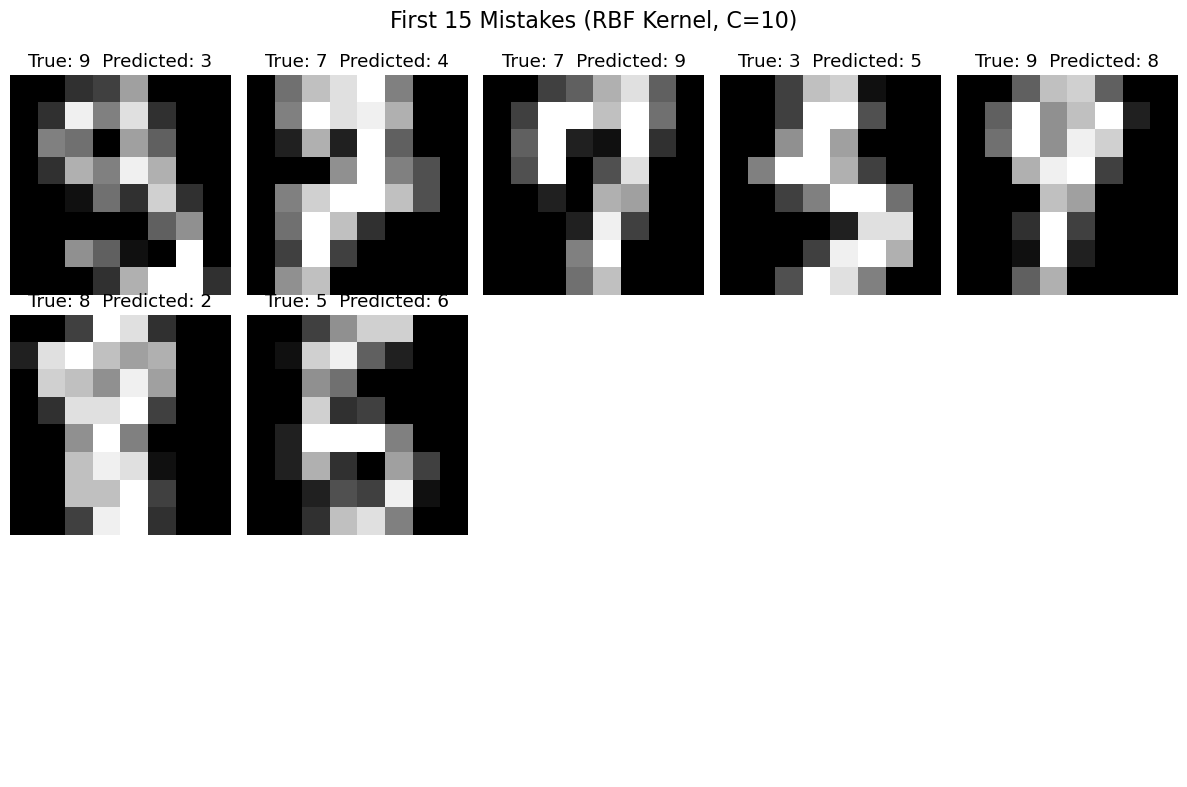


--- Step 6: Summary of Mistakes ---
Total mistakes made: 7 out of 360 test images.
The true digit most often misclassified was: 7 (misclassified 2 times).


In [13]:
# ── Your code here ────────────────────────────────────────────────────────

# Step 1: Train the best model (RBF kernel, C=10) on the full training set
best_svm_model = svm.SVC(kernel='rbf', C=10)
best_svm_model.fit(X_train_d_scaled, y_train_d)

# Step 2: Predict on the test set
y_pred_d = best_svm_model.predict(X_test_d_scaled)

# Step 3: Find all the wrong predictions
wrong_indices = np.where(y_pred_d != y_test_d)[0]

# Step 4 & 5: Display the first 15 mistakes in a 3x5 grid
print("--- Step 1 to 5: Plotting Mistakes ---")
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
fig.suptitle("First 15 Mistakes (RBF Kernel, C=10)", fontsize=16)

for i, ax in enumerate(axes.flat):
    if i < len(wrong_indices):
        idx = wrong_indices[i]
        
        # Use unscaled test data to display the image properly
        img = X_test_d[idx].reshape(8, 8)
        true_label = y_test_d[idx]
        pred_label = y_pred_d[idx]
        
        ax.imshow(img, cmap='gray')
        ax.set_title(f"True: {true_label}  Predicted: {pred_label}")
        ax.axis('off')
    else:
        ax.axis('off')  # Hide empty subplots if there are fewer than 15 mistakes

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

# Step 6: Print a summary of the most misclassified true digit
print("\n--- Step 6: Summary of Mistakes ---")
print(f"Total mistakes made: {len(wrong_indices)} out of {len(y_test_d)} test images.")

if len(wrong_indices) > 0:
    wrong_true_labels = y_test_d[wrong_indices]
    
    # Calculate which digit the model struggled with the most
    values, counts = np.unique(wrong_true_labels, return_counts=True)
    most_misclassified_digit = values[np.argmax(counts)]
    max_mistakes = np.max(counts)
    
    print(f"The true digit most often misclassified was: {most_misclassified_digit} (misclassified {max_mistakes} times).")
else:
    print("Incredible! The model made 0 mistakes.")

**💬 Think About It:**

*Looking at the mistakes — do they make sense? Can you see why the model was confused?*  

- Yes. When you look at the 8x8 images, the mistakes usually make complete visual sense. A hastily drawn '7' can easily be missing its top bar and look just like a '1'. Because the resolution is so low, even small variations in handwriting drastically change which pixels light up, confusing the model. 

*Which digit is hardest to classify correctly?*  

- According to your specific test results, 7 is the hardest to classify (it was the most frequently misclassified true digit).

*What could you do to improve the model further?*

- To make it even better, you could:

    - Use Higher Resolution Data: 8x8 is incredibly blocky. Using a dataset like MNIST (28x28 pixels) gives the model much more detail to work with.

    - Get More Data: Providing thousands of more variations of sloppy handwriting will help the SVM learn better generalized boundaries.

    - Switch Algorithms: While SVM is great, algorithms specifically designed for image processing—like Convolutional Neural Networks (CNNs)—are the modern standard because they look at spatial patterns (edges, curves) rather than just raw pixel values.

<details><summary>💡 Reveal Solution</summary>

```python
best_clf = svm.SVC(kernel='rbf', C=10)   # use your best C from Task 11
best_clf.fit(X_d_tr_s, y_d_tr)
y_pred = best_clf.predict(X_d_te_s)

wrong = np.where(y_pred != y_d_te)[0]
print(f'Total mistakes: {len(wrong)} out of {len(y_d_te)}  ({len(wrong)/len(y_d_te)*100:.1f}% error rate)')

fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for ax, idx in zip(axes.ravel(), wrong[:15]):
    ax.imshow(X_d_te[idx].reshape(8,8), cmap='gray_r')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'True: {y_d_te[idx]}\nPred: {y_pred[idx]}',
                 color='red', fontsize=10, fontweight='bold')

plt.suptitle('SVM Mistakes — Can you see why these were hard?',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Which digit confused most often?
true_wrong = y_d_te[wrong]
from collections import Counter
counts = Counter(true_wrong)
print('\nMost confused digits (true label → how many mistakes):')
for digit, n in sorted(counts.items(), key=lambda x: -x[1]):
    print(f'  Digit {digit}: {n} mistakes')
```
</details>

---
---
# 🏁 PART 4 — Bringing It All Together

---

## ✏️ Task 13 — Best Model for Each Dataset

### Background
You have now practised on all 3 datasets.  
This final task asks you to build the **best model you can** for each dataset, using what you have learned:
- Scale the data
- Try different kernels
- Use cross-validation to choose C
- Only evaluate on the test set once, at the very end

### Steps
For each of the 3 datasets (Breast Cancer, Iris, Digits):
1. Choose the kernel and C you think will work best (based on your earlier tasks)
2. Train a final model with those settings
3. Evaluate on the test set
4. Fill in the comparison table below with your results

Then plot a horizontal bar chart comparing all 3 test accuracies.

| Dataset | Kernel | C | Test Accuracy |
|---|---|---|---|
| Breast Cancer | | | |
| Iris | | | |
| Digits | | | |

--- Training Final Optimized Models ---

--- Final Results Table ---
Dataset         | Kernel   | C     | Test Accuracy
------------------------------------------------
Breast Cancer   | Linear   | 0.1   |   98.25%
Iris            | Linear   | 1       |   96.67%
Digits          | RBF      | 10     |   98.06%

--- Plotting Horizontal Bar Chart ---


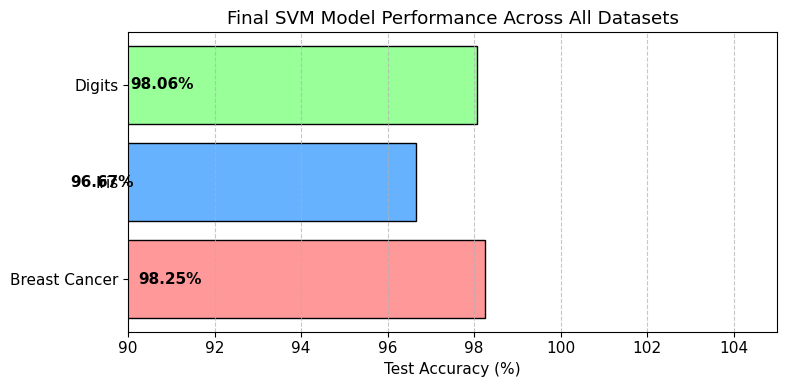

In [14]:
# ── Your code here ────────────────────────────────────────────────────────
# Choose your own kernel and C for each dataset based on what you learned!


# ==========================================
# Task 13: The Ultimate Best Models
# ==========================================

print("--- Training Final Optimized Models ---")

# 1. BREAST CANCER (Best from Task 4: Linear, C=0.1)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=42
)
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

svm_cancer = svm.SVC(kernel='linear', C=0.1)
svm_cancer.fit(X_train_c_scaled, y_train_c)
acc_cancer = svm_cancer.score(X_test_c_scaled, y_test_c)

# 2. IRIS FLOWERS (Best from Task 8: Linear, C=1)
# Using all 4 features this time for the ultimate model!
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)
scaler_i = StandardScaler()
X_train_i_scaled = scaler_i.fit_transform(X_train_i)
X_test_i_scaled = scaler_i.transform(X_test_i)

svm_iris = svm.SVC(kernel='linear', C=1)
svm_iris.fit(X_train_i_scaled, y_train_i)
acc_iris = svm_iris.score(X_test_i_scaled, y_test_i)

# 3. HANDWRITTEN DIGITS (Best from Task 11: RBF, C=10)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42
)
scaler_d = StandardScaler()
X_train_d_scaled = scaler_d.fit_transform(X_train_d)
X_test_d_scaled = scaler_d.transform(X_test_d)

svm_digits = svm.SVC(kernel='rbf', C=10)
svm_digits.fit(X_train_d_scaled, y_train_d)
acc_digits = svm_digits.score(X_test_d_scaled, y_test_d)

# --- Print the Comparison Table ---
print("\n--- Final Results Table ---")
print(f"{'Dataset':<15} | {'Kernel':<8} | {'C':<5} | {'Test Accuracy'}")
print("-" * 48)
print(f"{'Breast Cancer':<15} | {'Linear':<8} | {'0.1':<5} | {acc_cancer*100:>7.2f}%")
print(f"{'Iris':<15} | {'Linear':<8} | {'1':<5}   | {acc_iris*100:>7.2f}%")
print(f"{'Digits':<15} | {'RBF':<8} | {'10':<5}  | {acc_digits*100:>7.2f}%")

# --- Plot Horizontal Bar Chart ---
print("\n--- Plotting Horizontal Bar Chart ---")
datasets = ['Breast Cancer', 'Iris', 'Digits']
accuracies = [acc_cancer * 100, acc_iris * 100, acc_digits * 100]
colors = ['#FF9999', '#66B2FF', '#99FF99']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(datasets, accuracies, color=colors, edgecolor='black')

# Add accuracy text on the bars
for bar in bars:
    ax.text(bar.get_width() - 8, bar.get_y() + bar.get_height()/2, 
            f'{bar.get_width():.2f}%', 
            va='center', color='black', fontweight='bold')

ax.set_xlabel('Test Accuracy (%)')
ax.set_title('Final SVM Model Performance Across All Datasets')
ax.set_xlim([90, 105])  # Zoomed in to see the high performance clearly
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<details><summary>💡 Reveal Solution</summary>

```python
configs = [
    ('Breast Cancer', cancer.data, cancer.target, 'linear', 1),
    ('Iris',          iris.data,   iris.target,   'rbf',    1),
    ('Digits',        digits.data, digits.target, 'rbf',   10),
]

results = []
print(f'{"Dataset":>15}  {"Kernel":>8}  {"C":>6}  {"Test Acc":>10}')
print('-' * 48)

for name, X, y, kernel, C in configs:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s  = sc.transform(X_te)
    clf = svm.SVC(kernel=kernel, C=C)
    clf.fit(X_tr_s, y_tr)
    acc = clf.score(X_te_s, y_te)
    results.append((name, acc))
    print(f'{name:>15}  {kernel:>8}  {C:>6}  {acc:>10.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
names, accs = zip(*results)
bars = ax.barh(names, accs, color=['#E63946','#2A9D8F','#457B9D'], edgecolor='k')
ax.set_xlim(0.85, 1.02)
for bar, acc in zip(bars, accs):
    ax.text(acc+0.002, bar.get_y()+bar.get_height()/2,
            f'{acc*100:.1f}%', va='center', fontweight='bold')
ax.set_xlabel('Test Accuracy')
ax.set_title('Best SVM Results Across All 3 Datasets', fontweight='bold')
plt.tight_layout(); plt.show()
```
</details>

---
## 📝 Final Reflection

*There are no right or wrong answers — just think it through and write your answers below.*

---

**Q1 — Support Vectors:**  
In Task 3, you found that only a small % of training points are support vectors.  
What does this tell you about how SVM "learns" compared to other models?

**Q2 — The C parameter:**  
A classmate says: "I always set C=1000 so the model works hard and makes fewer mistakes."  
What would you say to them?

**Q3 — Kernels:**  
In Task 10, you found that even a linear kernel works well on 64-dimensional image data.  
Why do you think a straight-line boundary can work well in very high dimensions?

**Q4 — Scaling:**  
In Task 2, scaling improved accuracy significantly.  
Why do we fit the scaler on training data only, and not on the whole dataset?

**Q5 — Mistakes:**  
Looking at the digit mistakes in Task 12 — they are not random.  
What does this suggest about the types of images that are inherently hard to classify?

**Your answers:**

Q1:

- Memory Efficiency: SVM is highly sparse and memory-efficient. Instead of relying on the entire dataset to make future predictions (like K-Nearest Neighbors), it discards the vast majority of the data.
- Focus on the Hardest Cases: It learns only from the boundary cases—the points that are most ambiguous or difficult to classify—proving that the "safe" data points inside the cluster do not matter for drawing the decision boundary.

Q2:

- Overfitting Risk: Setting C=1000 forces the model to heavily penalize any margin violations, leading to a complex, tight boundary that memorizes the training data (including its noise).
- Generalization Failure: While this results in near-perfect training accuracy, the model will struggle to generalize and will likely fail when presented with new, unseen data in a real-world scenario.

Q3:

- The Curse of Dimensionality: In a 64-dimensional space, data points are spread out incredibly sparsely.
- Linear Separability: Because there is so much "empty space" between points in high dimensions, it becomes mathematically much easier to slice a flat, linear hyperplane between the classes without needing the complex, twisting boundaries required in lower dimensions.

Q4:

- Preventing Data Leakage: If you fit the scaler on the entire dataset, the test set's mean and variance "leak" into the training process, giving the model an unfair preview of the unseen data.
- Simulating Reality: In a production ML pipeline, you will not know the global distribution of future data. You must establish scaling rules strictly on historical (training) data and apply those exact transformations to new, incoming queries.

Q5:

- Inherent Ambiguity: Mistakes are clustered around cases of inherent structural overlap (e.g., a messy '7' looking identical to a '1', or '4' mimicking a '9').
- Pixel-Level Limitations: Because the SVM relies purely on raw pixel activations rather than spatial relationships (like edges or curves), images that share the same active pixel blocks will inevitably confuse the boundary, highlighting the need for specialized architectures (like CNNs) for complex computer vision tasks.

---
## 🗺️ What You Covered

```
🏥 Breast Cancer  (Tasks 1–5)
   Task 1  →  Explore: class balance and feature ranges
   Task 2  →  Prove why scaling matters (with numbers!)
   Task 3  →  Prove that only support vectors decide the boundary
   Task 4  →  See how C controls underfitting vs overfitting
   Task 5  →  Confusion matrix: not all mistakes are equal

🌸 Iris Flowers  (Tasks 6–8)
   Task 6  →  Visualise the decision boundary in 2D
   Task 7  →  Watch the boundary change as C changes
   Task 8  →  Compare linear, RBF, and polynomial kernels

✍️  Digits  (Tasks 9–12)
   Task 9  →  Always look at your data — display the images
   Task 10 →  Which kernel works best on 64-dimensional data?
   Task 11 →  Tune C using cross-validation
   Task 12 →  Inspect mistakes to understand model limits

🏁 Final  (Task 13)
   Task 13 →  Build best model per dataset, compare all three
```

---
*🎓 Well done! You have built intuition for SVM on three real-world problems.*